In [1]:
import matplotlib.pyplot as plt
from ledgerdata import Client

client = Client()

In [2]:
# this retrieves emissions for United States
# and stores it in a pandas dataframe
emissions = await client.emissions_async(actor_id="US")

# this shows the first few lines
# notice that years are out not ordered (I need to fix this in the API)
emissions.head()

,actor_id,year,emissions,units,assessment_report
0,US,1863,1.904720e+08,CO2 * tonne / yr,AR6
1,US,1919,1.937533e+09,CO2 * tonne / yr,AR6
2,US,1953,3.358792e+09,CO2 * tonne / yr,AR6
3,US,1920,2.235113e+09,CO2 * tonne / yr,AR6
4,US,1952,3.274792e+09,CO2 * tonne / yr,AR6


In [3]:
# we can sort the data
emissions = emissions.sort_values(by="year")
emissions.head()

,actor_id,year,emissions,units,assessment_report
33,US,1850,1.218970e+08,CO2 * tonne / yr,AR6
105,US,1851,1.299027e+08,CO2 * tonne / yr,AR6
169,US,1852,1.348344e+08,CO2 * tonne / yr,AR6
47,US,1853,1.411628e+08,CO2 * tonne / yr,AR6
59,US,1854,1.470576e+08,CO2 * tonne / yr,AR6


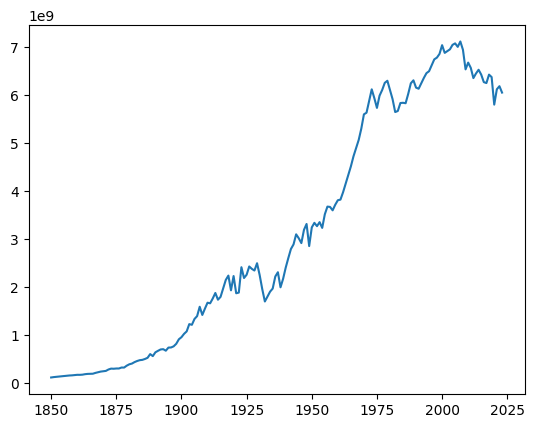

In [4]:
# basic plot 
plt.plot(emissions.year, emissions.emissions)

Text(0.5, 1.0, 'U.S. Total Emissions')

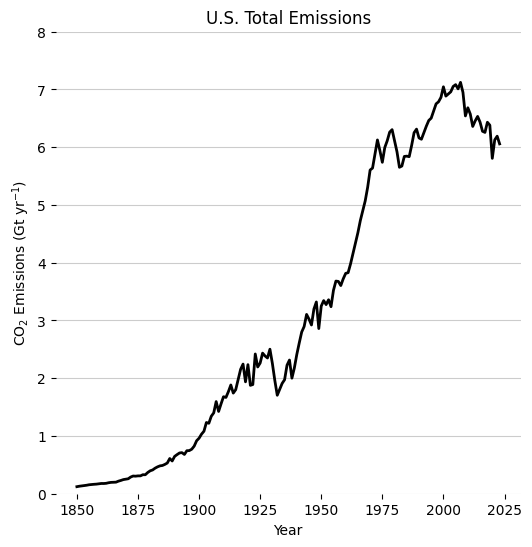

In [5]:
import matplotlib.pyplot as plt

# conversion factor
tonnes_to_gigatonne = 1E-9

# create figure (fig) and axis (ax) objects
# we plot on the axis 
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)

# Turn off the display of all ticks.
ax.tick_params(which='both',     # Options for both major and minor ticks
               top='off',        # turn off top ticks
               left='off',       # turn off left ticks
               right='off',      # turn off right ticks
               bottom='off')     # turn off bottom ticks

# Remove x tick marks
plt.setp(ax.get_xticklabels(), rotation=0)

# Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Only show ticks on the left and bottom spines
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

# grid and tick marks
ax.set_ylim(ymin=0, ymax=8)
ax.set_yticks(range(0, 9, 1))
ax.grid(axis='y',
        which='major',
        color=[0.8, 0.8, 0.8], linestyle='-')

# plot emissions
ax.plot(emissions.year, emissions.emissions * tonnes_to_gigatonne, 
        color='k', 
        label="United States", 
        linewidth=2)

# set labels
ax.set_xlabel("Year")
ax.set_ylabel("CO$_2$ Emissions (Gt yr$^{-1}$)")
ax.set_title("U.S. Total Emissions")
